In [1]:
import sys

import matplotlib.pyplot as plt
import torch

sys.path.append("../")
from datasets.dataloader import get_wireless_dataloader
from models.encoder import EncoderConfig, WirelessEncoder

dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    drop_last=True,
)

In [2]:
data = next(iter(dataloader))
rx_position = data["rx_position"].squeeze()  # [3]
channel_matrix = data["channel_matrix"].squeeze()  # [tx_ant, rx_ant, 2]
aoa = data["aoa"][0]  # [2, num_paths], 2 for azimuth and elevation
path_loss = data["path_loss"]  # [1]
path_loss_per_ray = data["path_loss_per_ray"][0]  # [num_paths]

In [ ]:
# move data to GPU
num_points = 16378
points = dataloader.dataset.get_point_cloud(num_points).cuda()
tx_pos = dataloader.dataset.get_tx_position().cuda()
rx_position = rx_position.cuda()
path_loss = path_loss.cuda()
aoa = aoa.cuda()
path_loss_per_ray = path_loss_per_ray.cuda()

# create encoder configuration (both attention and masking)
config_attention = EncoderConfig(
    hidden_size=128,
    num_layers=8,
    skip_layers=(4,),
    input_pos_multires=10,
    path_encode_dim=32,
    use_attention=True,
    max_paths=10,
    is_indoor=True,
)

config_masking = EncoderConfig(
    hidden_size=128,
    num_layers=8,
    skip_layers=(4,),
    input_pos_multires=10,
    path_encode_dim=32,
    use_attention=False,
    max_paths=10,
    is_indoor=True,
)

# initialize both encoders
encoder_attention = WirelessEncoder(config_attention).cuda()
encoder_masking = WirelessEncoder(config_masking).cuda()

In [4]:
# run forward pass with attention-based encoder
output_attention = encoder_attention(
    points,
    tx_pos,
    rx_position,
    path_loss,
    aoa,
    path_loss_per_ray,
)

# run forward pass with masking-based encoder
output_masking = encoder_masking(
    points,
    tx_pos,
    rx_position,
    path_loss,
    aoa,
    path_loss_per_ray,
)

# check output shapes
print("\nAttention-based encoder output shapes:")
for key, value in output_attention.items():
    print(f"- {key}: {value.shape}")

print("\nMasking-based encoder output shapes:")
for key, value in output_masking.items():
    print(f"- {key}: {value.shape}")


Attention-based encoder output shapes:
- attenuation: torch.Size([16378, 1])
- phase_rotation: torch.Size([16378, 1])

Masking-based encoder output shapes:
- attenuation: torch.Size([16378, 1])
- phase_rotation: torch.Size([16378, 1])


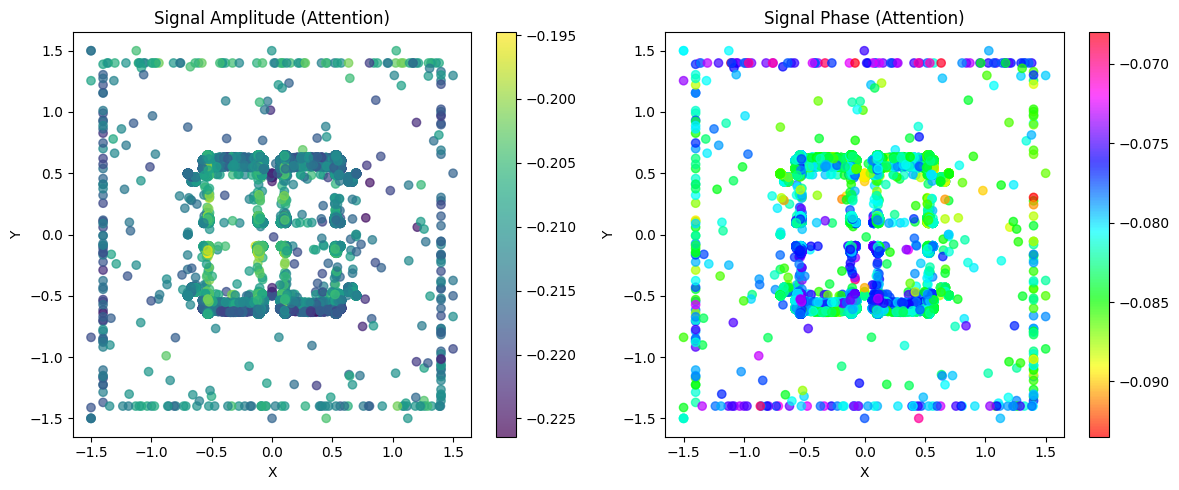

In [6]:
# visualize features from attention-based encoder
points_np = points.cpu().numpy()
plot_attention = False

if plot_attention:
    attenuation = output_attention["attenuation"].detach().cpu().numpy()
    phase_rotation = output_attention["phase_rotation"].detach().cpu().numpy()
else:
    attenuation = output_masking["attenuation"].detach().cpu().numpy()
    phase_rotation = output_masking["phase_rotation"].detach().cpu().numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    points_np[:, 0],
    points_np[:, 1],
    c=attenuation[:],
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar()
plt.title("Signal Amplitude (Attention)")
plt.xlabel("X")
plt.ylabel("Y")

plt.subplot(1, 2, 2)
plt.scatter(
    points_np[:, 0],
    points_np[:, 1],
    c=phase_rotation[:],
    cmap="hsv",
    alpha=0.7,
)
plt.colorbar()
plt.title("Signal Phase (Attention)")
plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()
plt.show()